# Phase 1: 00 — Data Preprocessing & Exploratory Analysis
## Analisis Sentimen Bencana Banjir (Dataset Data V2)

**Tujuan Notebook:**
1. Membaca dataset utama `datav2` (`banjir_processed_v2.csv` / `data_banjir.csv`).
2. Melakukan audit dan seluruh tahapan pembersihan teks berbasis regex (*URL, mention, hashtag, noise removal*).
3. Standardisasi kata gaul/slang ke bentuk baku menggunakan kamus leksikon `colloquial-indonesian-lexicon.csv`.
4. Eksplorasi Data (EDA): Visualisasi Word Cloud (keseluruhan korpus dan per kelas sentimen) serta analisis distribusi frekuensi sentimen.
5. Menjalankan *Stratified Train/Validation/Test Split* (72% Train, 8% Val, 20% Test) dengan kunci acak deterministik `random_state=42`.
6. Menyimpan file data partisi terstandarisasi (`data_v2.csv`, `train.csv`, `validation.csv`, `test.csv`) agar seluruh eksperimen pemodelan berikutnya menggunakan data yang identik (*Zero Data Leakage*).


### 1. Import Library

In [2]:
import os
import sys
from pathlib import Path

# Setup paths (kompatibel eksekusi langsung dari script_thesis/ atau project root)
CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "script_thesis":
    BASE_DIR = CURRENT_DIR
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR
    BASE_DIR = PROJECT_ROOT / "script_thesis"

DATA_DIR = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUTS_DIR / "figures"
METRIC_DIR = OUTPUTS_DIR / "metrics"
CM_DIR = OUTPUTS_DIR / "confusion_matrix"
MODEL_DIR = OUTPUTS_DIR / "models"

for p in [DATA_DIR, FIG_DIR, METRIC_DIR, CM_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Dir    : {DATA_DIR}")
print(f"Outputs Dir : {OUTPUTS_DIR}")

import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 150


Project Root: d:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT
Data Dir    : d:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\data
Outputs Dir : d:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs


### 2. Load Dataset Utama (Data V2)

In [4]:
# Pencarian dataset kandidat
candidates = [
    PROJECT_ROOT / "Data" / "processed" / "banjir_processed_v2.csv",
    PROJECT_ROOT / "Data" / "processed" / "data_preprocessed_v2.csv",
    PROJECT_ROOT / "Data" / "raw" / "banjir.csv",
    PROJECT_ROOT / "Data" / "data_banjir.csv",
    PROJECT_ROOT / "kaggle_dataset" / "banjir_processed_v2.csv",
]

data_path = None
for c in candidates:
    if c.exists():
        data_path = c
        break

if data_path is None:
    raise FileNotFoundError("Dataset utama banjir tidak ditemukan di kandidat path.")

print(f"Memuat dataset dari: {data_path}")
df_raw = pd.read_csv(data_path)
print(f"Total baris data: {len(df_raw):,} sampel")
print("Kolom tersedia:", list(df_raw.columns))
df_raw.head(3)


Memuat dataset dari: d:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\Data\processed\banjir_processed_v2.csv
Total baris data: 8,648 sampel
Kolom tersedia: ['text', 'clean_text', 'created_at', 'keyword', 'processed_text', 'sentimen', 'label', 'emoticon', 'is_truncated', 'clean_text_step1', 'processed_text_v2']


,text,clean_text,created_at,keyword,processed_text,sentimen,label,emoticon,is_truncated,clean_text_step1,processed_text_v2
0,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit menemukan siapa pemilik kayu yg m...,2026-01-13,Banjir Sumatra 2025,polisi sulit temu siapa milik kayu sebab banji...,negatif,0,NaN,False,Polisi : Sulit menemukan siapa pemilik kayu yg...,Polisi : Sulit menemukan siapa pemilik kayu ya...
1,Seorang Ibu harus memanjat tebing demi membawa...,seorang ibu harus memanjat tebing demi membawa...,2026-01-13,Banjir Sumatra 2025,orang ibu panjat tebing bawa bayi puskesmas ga...,negatif,0,NaN,False,Seorang Ibu harus memanjat tebing demi membawa...,Seorang Ibu harus memanjat tebing demi membawa...
2,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,waspada banjir pesisir durasi januari,2026-01-13,Banjir Sumatra 2025,waspada banjir pesisir durasi januari,netral,1,NaN,False,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...


### 3. Konfigurasi Parameter Preprocessing & Split

In [5]:
SEED = 42
TEST_RATIO = 0.20       # 20% Holdout Test Set
VAL_RATIO_OF_TRAIN = 0.10 # 10% dari Train+Val -> 8% total dataset (72% Train, 8% Val, 20% Test)

np.random.seed(SEED)
print(f"Random Seed Terkunci: {SEED}")
print(f"Partisi Rasio: Train 72% | Validation 8% | Test 20%")


Random Seed Terkunci: 42
Partisi Rasio: Train 72% | Validation 8% | Test 20%


### 4. Pipeline Preprocessing Teks
1. **Regex Cleaning**: Menghapus URL, User Mention (`@user`), entitas HTML, angka engagement scraping, dan tanda hashtag (`#`).
2. **Kamus Leksikon Slang**: Standardisasi kata informal menggunakan `kamus/colloquial-indonesian-lexicon.csv`.
3. **Standarisasi Label**: Memetakan sentimen ke integer (`negatif: 0`, `netral: 1`, `positif: 2`).


In [ ]:
def clean_tweet_regex(text):
    text = str(text)
    # Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Hapus user mention
    text = re.sub(r'@\w+', '', text)
    # Hapus hashtag symbol (#banjir -> banjir)
    text = re.sub(r'#(\w+)', r'\1', text)
    # Hapus angka engagement trailing (misal: 2 rb, 35 rb)
    text = re.sub(r'\b\d+\s*(rb|jt)?\b', '', text, flags=re.IGNORECASE)
    # Normalisasi spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Load kamus colloquial
kamus_file = PROJECT_ROOT / "kamus" / "colloquial-indonesian-lexicon.csv"
slang_dict = {}
if kamus_file.exists():
    df_kamus = pd.read_csv(kamus_file)
    slang_dict = dict(zip(df_kamus['slang'].astype(str).str.lower(), df_kamus['formal'].astype(str)))
    print(f"Kamus slang dimuat: {len(slang_dict):,} entri")
else:
    print("Warning: Kamus leksikon tidak ditemukan, menggunakan normalisasi regex murni.")

def normalize_slang(text, mapping):
    words = str(text).split()
    return ' '.join([mapping.get(w.lower(), w) for w in words])

# Terapkan pembersihan
text_col = 'text' if 'text' in df_raw.columns else df_raw.columns[0]
label_col = 'label' if 'label' in df_raw.columns else 'sentimen'

df_clean = df_raw.copy()
df_clean['clean_regex'] = df_clean[text_col].apply(clean_tweet_regex)
df_clean['processed_text_v2'] = df_clean['clean_regex'].apply(lambda t: normalize_slang(t, slang_dict))

# Pastikan label integer (0: Negatif, 1: Netral, 2: Positif)
if df_clean[label_col].dtype == object:
    label_map = {'negatif': 0, 'netral': 1, 'positif': 2, 'negative': 0, 'neutral': 1, 'positive': 2}
    df_clean['label'] = df_clean[label_col].str.lower().map(label_map).fillna(0).astype(int)
else:
    df_clean['label'] = df_clean[label_col].astype(int)

# Simpan kolom teks kanonik
df_clean['text_clean'] = df_clean['processed_text_v2']
print("Contoh Pembersihan Teks:")
print("Mentah :", df_clean[text_col].iloc[0][:120], "...")
print("Bersih :", df_clean['text_clean'].iloc[0][:120], "...")


Kamus slang dimuat: 4,331 entri
Contoh Pembersihan Teks:
Mentah : Polisi : Sulit menemukan siapa pemilik kayu yg menyebabkan banjir Sumatra akhir 2025. Rakyat : Polisi Goblok, Percuma se ...
Bersih : Polisi : Sulit menemukan siapa pemilik kayu yang menyebabkan banjir Sumatra akhir . Rakyat : Polisi Goblok, Percuma seko ...


### 5. Analisis Statistik Distribusi Kelas Sentimen

Statistik Distribusi Sentimen:


,Jumlah Sampel,Persentase (%)
Negatif (0),4686,54.19
Netral (1),1510,17.46
Positif (2),2452,28.35


Tabel statistik tersimpan di: d:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\metrics\distribusi_kelas.csv


C:\Windows\Temp\ipykernel_8664\3069468228.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_df.index, y=dist_df['Jumlah Sampel'], ax=axes[0], palette=colors)


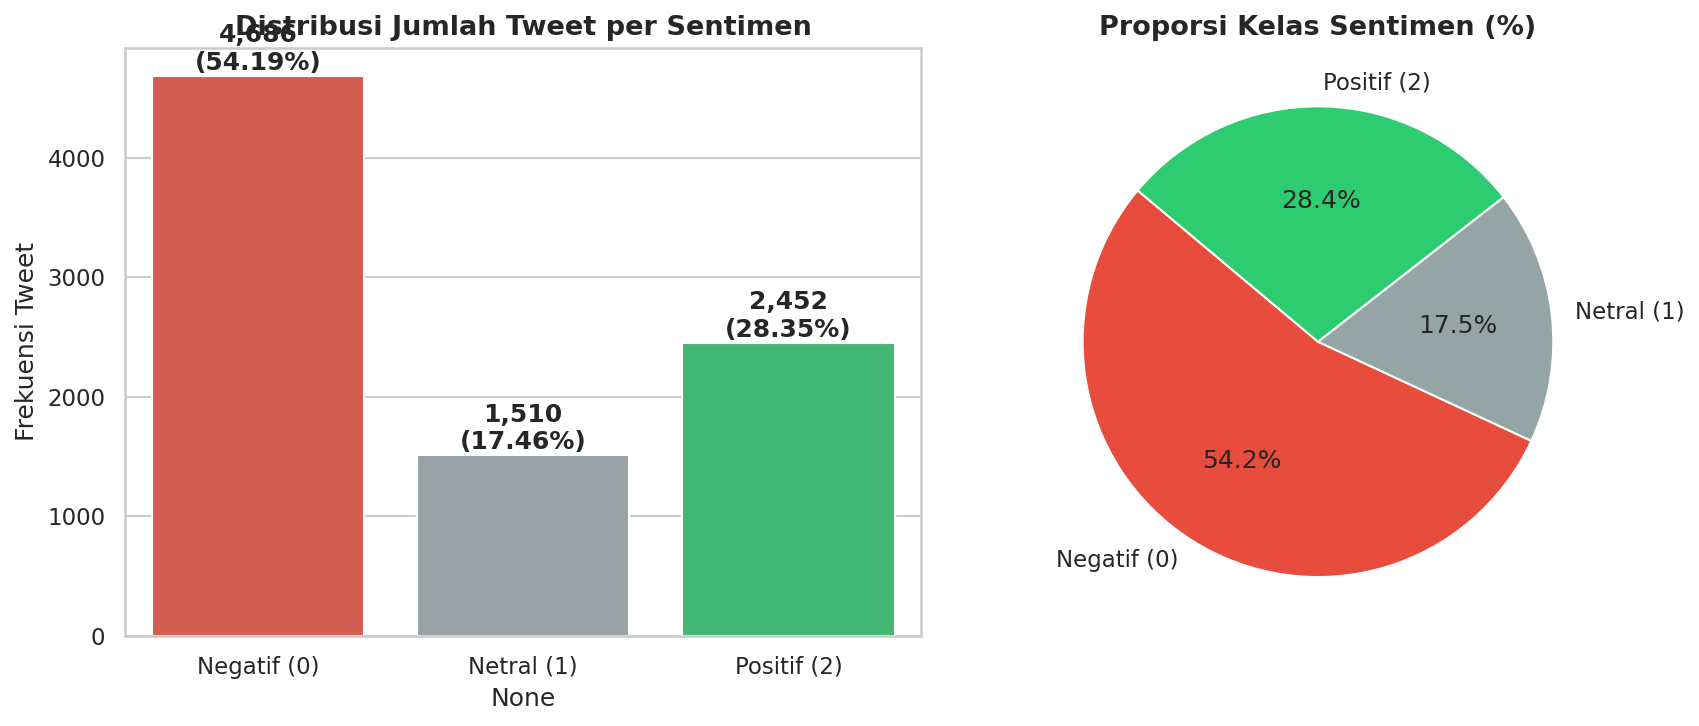

Gambar distribusi kelas tersimpan di: d:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\figures\distribusi_kelas.png


In [7]:
# Hitung frekuensi dan persentase
dist_df = pd.DataFrame({
    'Jumlah Sampel': df_clean['label'].value_counts().sort_index(),
    'Persentase (%)': (df_clean['label'].value_counts(normalize=True).sort_index() * 100).round(2)
})
dist_df.index = ['Negatif (0)', 'Netral (1)', 'Positif (2)']
print("Statistik Distribusi Sentimen:")
display(dist_df)

# Simpan tabel statistik
dist_df.to_csv(METRIC_DIR / "distribusi_kelas.csv")
print(f"Tabel statistik tersimpan di: {METRIC_DIR / 'distribusi_kelas.csv'}")

# Visualisasi Bar Plot & Pie Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#e74c3c', '#95a5a6', '#2ecc71']
# Bar Plot
sns.barplot(x=dist_df.index, y=dist_df['Jumlah Sampel'], ax=axes[0], palette=colors)
axes[0].set_title("Distribusi Jumlah Tweet per Sentimen", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Frekuensi Tweet")
for i, v in enumerate(dist_df['Jumlah Sampel']):
    axes[0].text(i, v + 50, f"{v:,}\n({dist_df['Persentase (%)'].iloc[i]}%)", ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(dist_df['Jumlah Sampel'], labels=dist_df.index, autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title("Proporsi Kelas Sentimen (%)", fontsize=13, fontweight='bold')

plt.tight_layout()
dist_fig_path = FIG_DIR / "distribusi_kelas.png"
plt.savefig(dist_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gambar distribusi kelas tersimpan di: {dist_fig_path}")


### 6. Visualisasi Word Cloud (Keseluruhan & per Kelas)

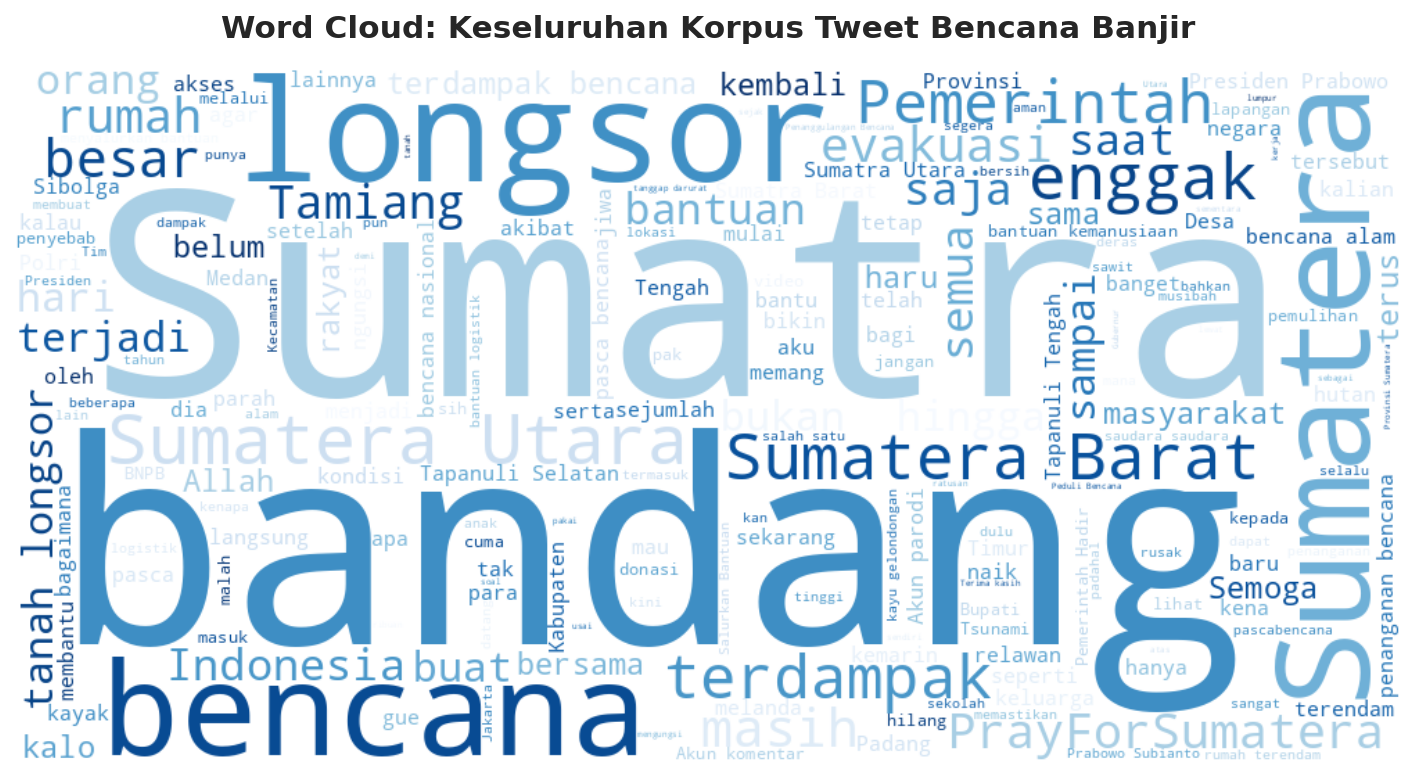

Word Cloud Keseluruhan tersimpan di: d:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\figures\wordcloud_keseluruhan.png


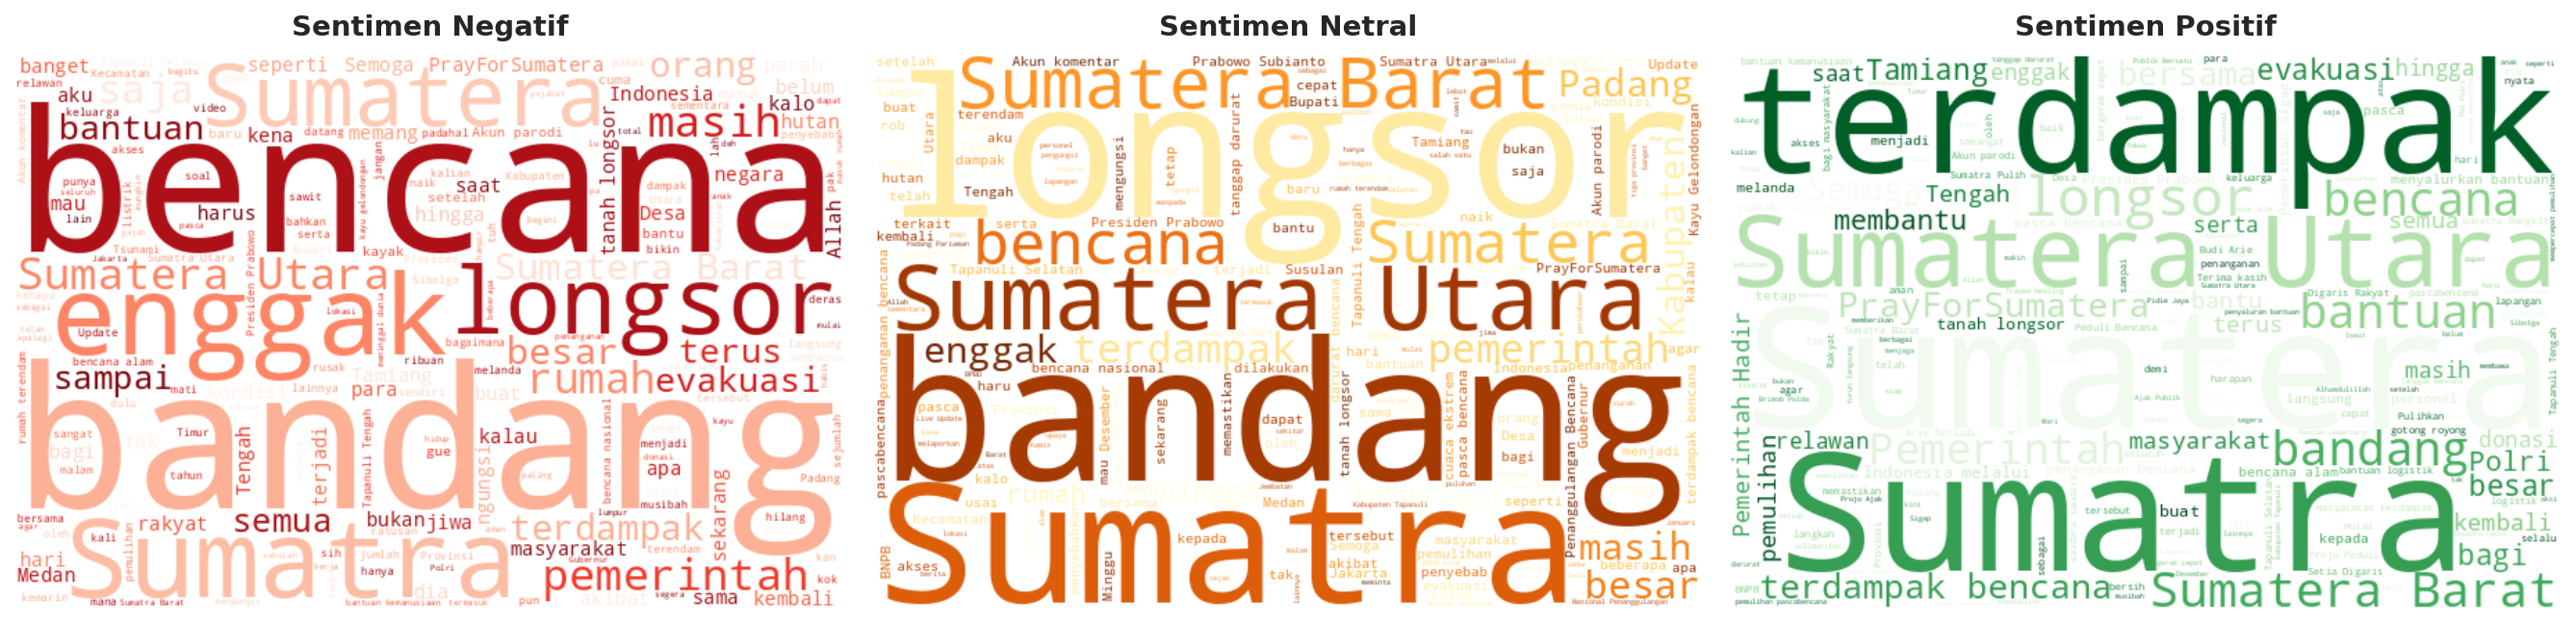

Word Cloud per Kelas tersimpan di: d:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\figures\wordcloud_per_kelas.png


In [8]:
# Custom Stopwords bahasa Indonesia untuk visualisasi
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'yang', 'dan', 'untuk', 'ini', 'itu', 'di', 'ke', 'dari', 'dengan', 'pada', 'adalah',
    'akan', 'sudah', 'ada', 'juga', 'tidak', 'bisa', 'lebih', 'kita', 'saya', 'kami', 'mereka',
    'atau', 'tapi', 'karena', 'jadi', 'lagi', 'banyak', 'dalam', 'ya', 'ga', 'yg', 'nya',
    'sumut', 'sumbar', 'sumsel', 'riau', 'jambi', 'lampung', 'banjir', 'warga', 'korban',
    'air', 'hujan', 'wilayah', 'daerah', 'aceh', 'kota', 'sungai', 'jalan'
])

# 1. WordCloud Keseluruhan Data
text_all = " ".join(df_clean['text_clean'].dropna().tolist())
wc_all = WordCloud(width=1000, height=500, background_color='white', stopwords=custom_stopwords, colormap='Blues').generate(text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud: Keseluruhan Korpus Tweet Bencana Banjir", fontsize=15, fontweight='bold', pad=15)
wc_all_path = FIG_DIR / "wordcloud_keseluruhan.png"
plt.savefig(wc_all_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Word Cloud Keseluruhan tersimpan di: {wc_all_path}")

# 2. WordCloud per Kelas Sentimen
sentimen_names = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
cmaps = {0: 'Reds', 1: 'YlOrBr', 2: 'Greens'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, label_val in enumerate([0, 1, 2]):
    subset_text = " ".join(df_clean[df_clean['label'] == label_val]['text_clean'].dropna().tolist())
    wc_sub = WordCloud(width=600, height=400, background_color='white', stopwords=custom_stopwords, colormap=cmaps[label_val]).generate(subset_text)
    axes[i].imshow(wc_sub, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f"Sentimen {sentimen_names[label_val]}", fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
wc_per_class_path = FIG_DIR / "wordcloud_per_kelas.png"
plt.savefig(wc_per_class_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Word Cloud per Kelas tersimpan di: {wc_per_class_path}")


### 7. Stratified Dataset Split & Penyimpanan Standar

In [9]:
# 1. Split Train+Val vs Test (80:20)
tr_val_df, test_df = train_test_split(
    df_clean, test_size=TEST_RATIO, stratify=df_clean['label'], random_state=SEED
)

# 2. Split Train vs Val (90:10 dari sisa 80% -> 72% Train, 8% Val)
train_df, val_df = train_test_split(
    tr_val_df, test_size=VAL_RATIO_OF_TRAIN, stratify=tr_val_df['label'], random_state=SEED
)

print(f"Partisi Data Siap Pakai (Seed = {SEED}):")
print(f"  • Train Set      : {len(train_df):,} tweet ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"  • Validation Set : {len(val_df):,} tweet ({len(val_df)/len(df_clean)*100:.1f}%)")
print(f"  • Test Set       : {len(test_df):,} tweet ({len(test_df)/len(df_clean)*100:.1f}%)")

# Verifikasi konsistensi distribusi label antar-partisi
split_summary = pd.DataFrame({
    'Train (%)': (train_df['label'].value_counts(normalize=True) * 100).round(2),
    'Val (%)': (val_df['label'].value_counts(normalize=True) * 100).round(2),
    'Test (%)': (test_df['label'].value_counts(normalize=True) * 100).round(2),
})
split_summary.index = ['Negatif (0)', 'Positif (2)', 'Netral (1)']
display(split_summary)

# Simpan CSV hasil split ke direktori data/
df_clean.to_csv(DATA_DIR / "data_v2.csv", index=False)
train_df.to_csv(DATA_DIR / "train.csv", index=False)
val_df.to_csv(DATA_DIR / "validation.csv", index=False)
test_df.to_csv(DATA_DIR / "test.csv", index=False)

print(f"Seluruh dataset terstandarisasi berhasil disimpan ke folder: {DATA_DIR}")


Partisi Data Siap Pakai (Seed = 42):
  • Train Set      : 6,226 tweet (72.0%)
  • Validation Set : 692 tweet (8.0%)
  • Test Set       : 1,730 tweet (20.0%)


,Train (%),Val (%),Test (%)
Negatif (0),54.19,54.19,54.16
Positif (2),28.35,28.32,28.38
Netral (1),17.46,17.49,17.46


Seluruh dataset terstandarisasi berhasil disimpan ke folder: d:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\data


### 8. Kesimpulan Singkat
1. **Pembersihan Teks Sukses**: Artefak scraping dan kata slang dinormalisasi tanpa menghilangkan struktur gramatikal kalimat.
2. **Karakteristik Data**: Distribusi data menunjukkan dominasi sentimen negatif (54,2%), diikuti positif (28,3%), dan netral sebagai kelas minoritas (17,5%).
3. **Reproducibility Terkunci**: Data Train, Validation, dan Test telah disimpan terpisah secara permanen dengan `seed=42`, siap digunakan oleh seluruh notebook pemodelan 01 hingga 06 tanpa risiko kebocoran data.
